## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_palette("Set2")

## 2.Load Dataset

In [16]:
df = pd.read_csv("Retail_Sales_cleaned.csv")

df.head()

,transaction_id,date,customer_id,gender,age,product_category,quantity,price_per_unit,total_amount,year,month,month_name,day,day_name,quarter,is_weekend,age_group,month_name.1
0,1,11/24/2023,CUST001,Male,34,Beauty,3,50,150,2023,11,November,24,Friday,4,False,Adult,November
1,2,2/27/2023,CUST002,Female,26,Clothing,2,500,1000,2023,2,February,27,Monday,1,False,Adult,February
2,3,1/13/2023,CUST003,Male,50,Electronics,1,30,30,2023,1,January,13,Friday,1,False,Middle Age,January
3,4,5/21/2023,CUST004,Male,37,Clothing,1,500,500,2023,5,May,21,Sunday,2,True,Middle Age,May
4,5,5/6/2023,CUST005,Male,30,Beauty,2,50,100,2023,5,May,6,Saturday,2,True,Adult,May


## 3. Dataset Overview

In [17]:
df.shape

(1000, 18)

In [18]:
df.columns

Index(['transaction_id', 'date', 'customer_id', 'gender', 'age',
       'product_category', 'quantity', 'price_per_unit', 'total_amount',
       'year', 'month', 'month_name', 'day', 'day_name', 'quarter',
       'is_weekend', 'age_group', 'month_name.1'],
      dtype='str')

In [19]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
transaction_id,1000.0,500.500,288.819436,1.0,250.75,500.5,750.25,1000.0
age,1000.0,41.392,13.681430,18.0,29.00,42.0,53.00,64.0
quantity,1000.0,2.514,1.132734,1.0,1.00,3.0,4.00,4.0
price_per_unit,1000.0,179.890,189.681356,25.0,30.00,50.0,300.00,500.0
total_amount,1000.0,456.000,559.997632,25.0,60.00,135.0,900.00,2000.0
year,1000.0,2023.002,0.044699,2023.0,2023.00,2023.0,2023.00,2024.0
month,1000.0,6.549,3.452755,1.0,4.00,6.0,10.00,12.0
day,1000.0,15.310,8.871674,1.0,7.00,15.0,23.00,31.0
quarter,1000.0,2.525,1.119208,1.0,2.00,2.0,4.00,4.0


## 4. Numerical Distribution

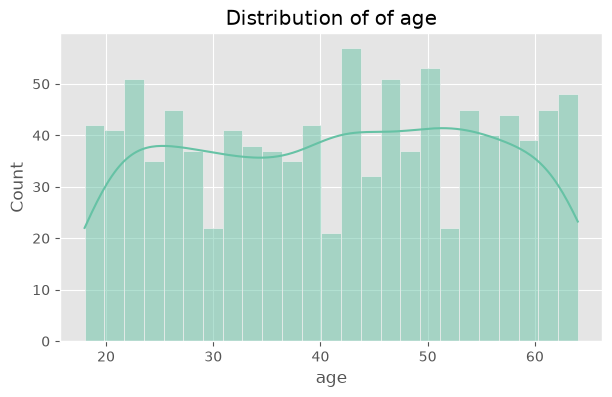

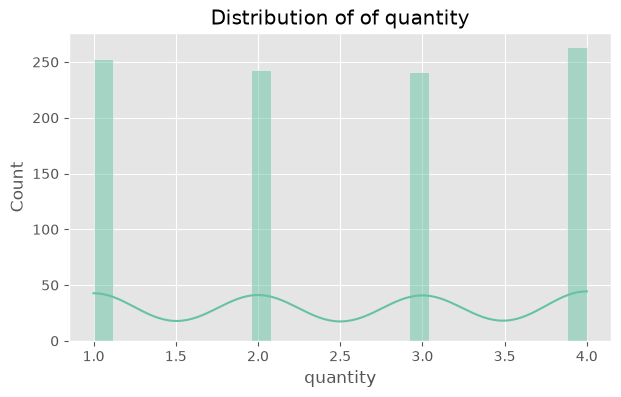

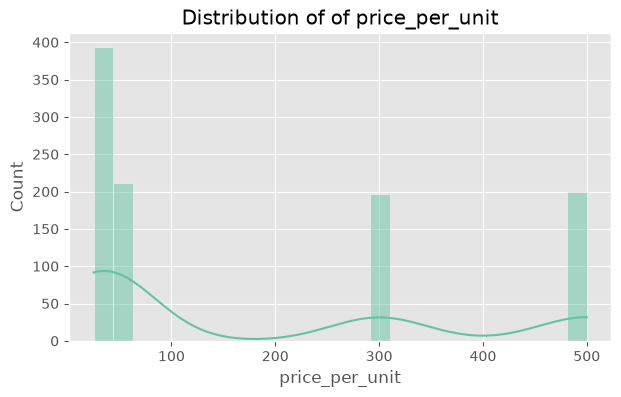

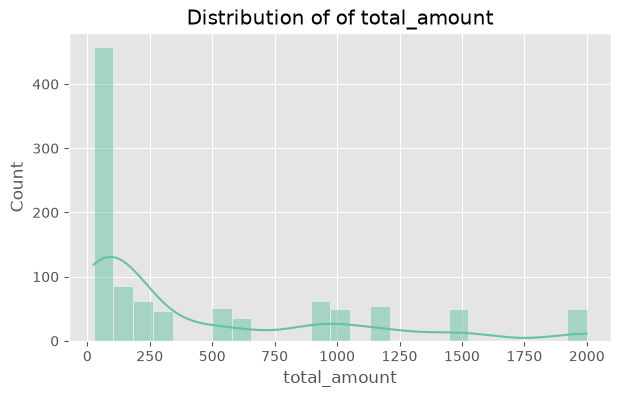

In [20]:
numerical_col = [
    "age",
    "quantity",
    "price_per_unit",
    "total_amount"
]

for col in numerical_col:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col],bins=25,kde=True)
    plt.title(f"Distribution of of {col}")
    plt.show()

## 5. Product Category Distribution

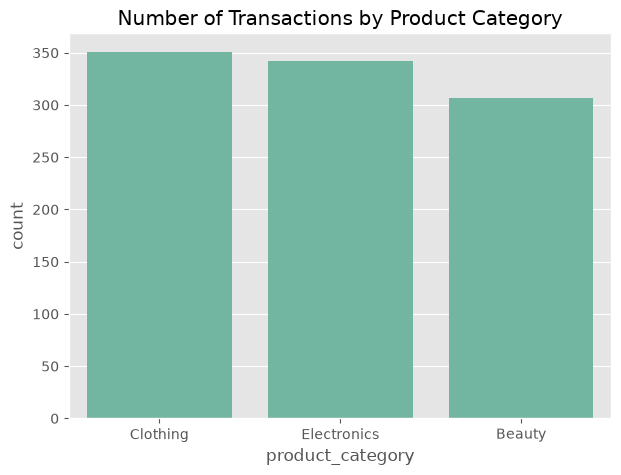

In [21]:
plt.figure(figsize=(7,5))
sns.countplot(
    data=df,
    x="product_category",
    order=df["product_category"].value_counts().index
)
plt.title("Number of Transactions by Product Category")
plt.show()

## 6. Gender Distribution

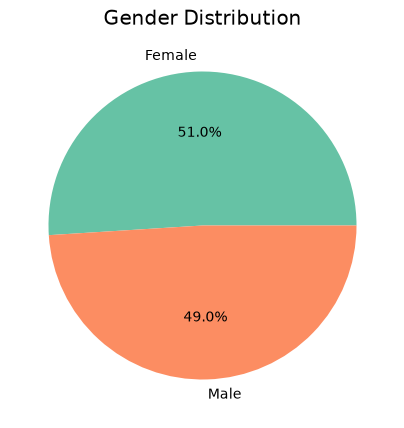

In [22]:
plt.figure(figsize=(5,5))
df["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)
plt.ylabel("")
plt.title("Gender Distribution")
plt.show()

## 7. Monthly Sales Trend

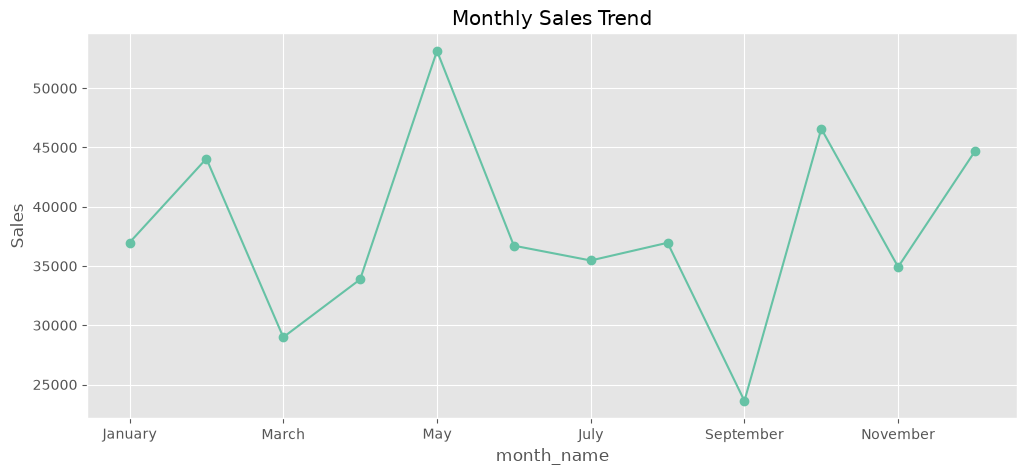

In [23]:
monthly_sales = (
    df.groupby("month_name")["total_amount"]
      .sum()
      .reindex([
          "January","February","March",
          "April","May","June",
          "July","August","September",
          "October","November","December"
      ])
)

plt.figure(figsize=(12,5))

monthly_sales.plot(marker="o")

plt.title("Monthly Sales Trend")

plt.ylabel("Sales")

plt.show()

## 8. Category Wise Revenue

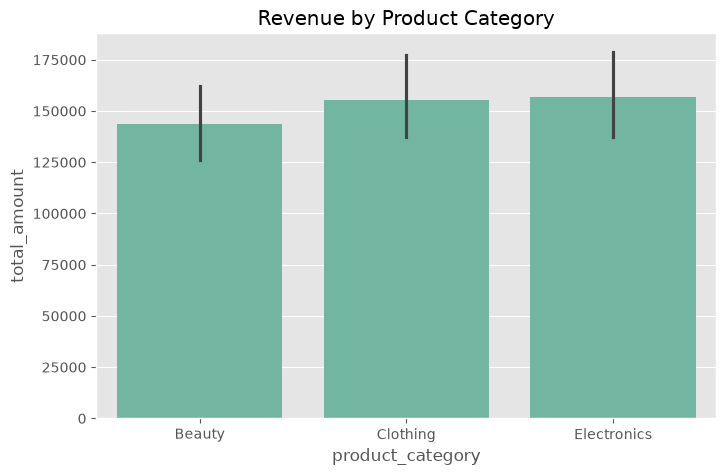

In [25]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=df,
    x="product_category",
    y="total_amount",
    estimator=sum
)
plt.title("Revenue by Product Category")
plt.show()

## 9. Quantity Sold

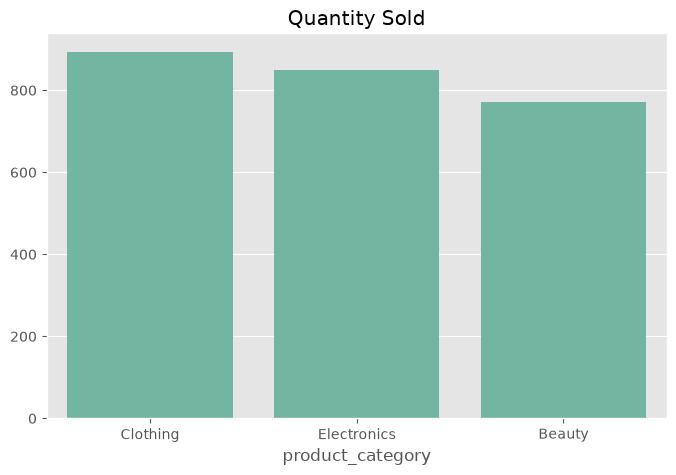

In [27]:
quantity = (
    df.groupby("product_category")["quantity"]
      .sum()
      .sort_values(ascending=False)
)
plt.figure(figsize=(8,5))
sns.barplot(
    x=quantity.index,
    y=quantity.values
)
plt.title("Quantity Sold")
plt.show()

## 10. Gender vs Spending

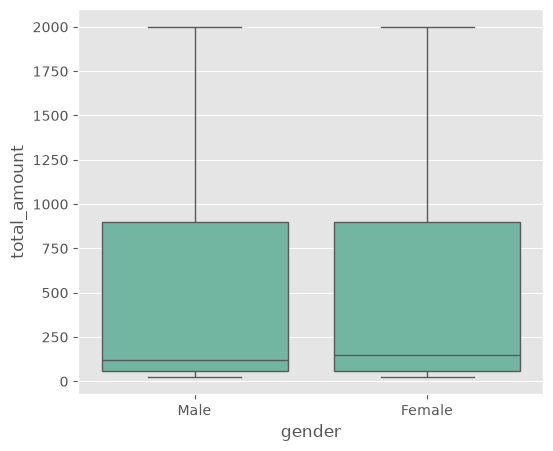

In [28]:
plt.figure(figsize=(6,5))
sns.boxplot(
    data=df,
    x="gender",
    y="total_amount"
)
plt.show()

## 11. Product Category vs Sales

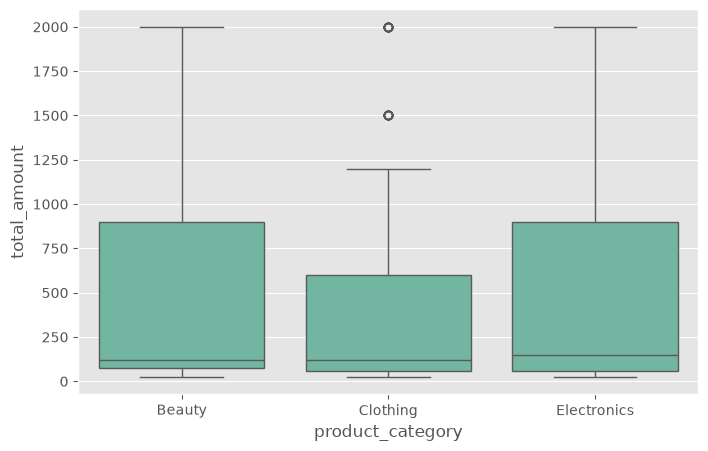

In [30]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="product_category",
    y="total_amount"
)
plt.show()

## 12. Age vs Spending

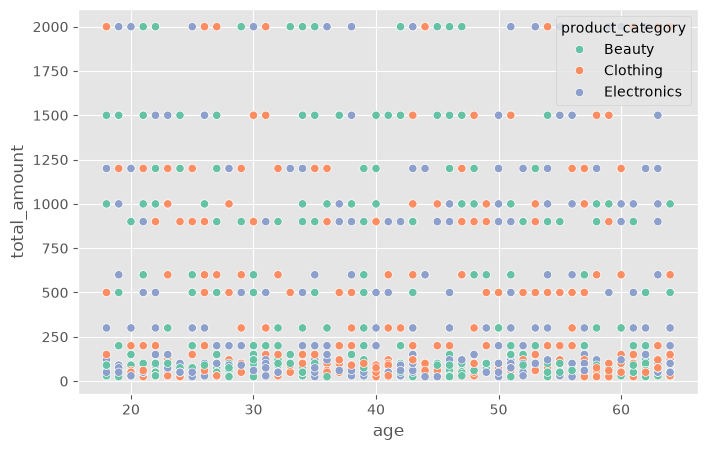

In [31]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="age",
    y="total_amount",
    hue="product_category"
)
plt.show()

## 13. Correlation Heatmap

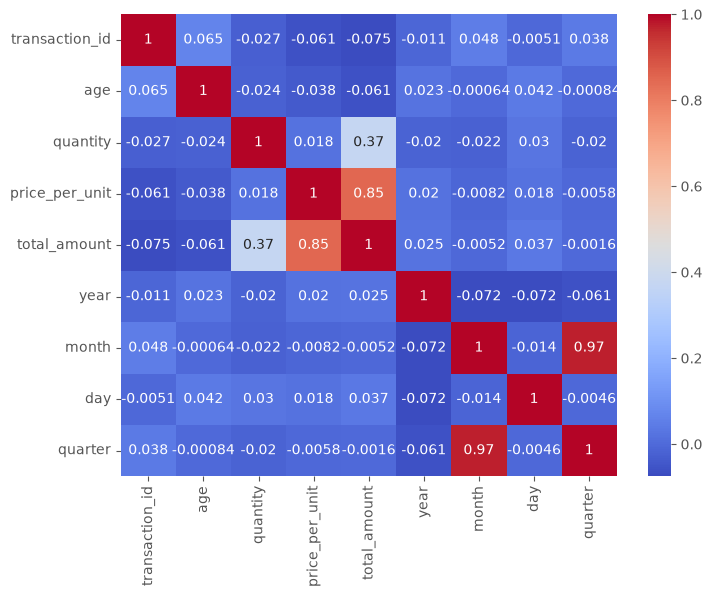

In [32]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm"
)
plt.show()

## 14. Top Customers

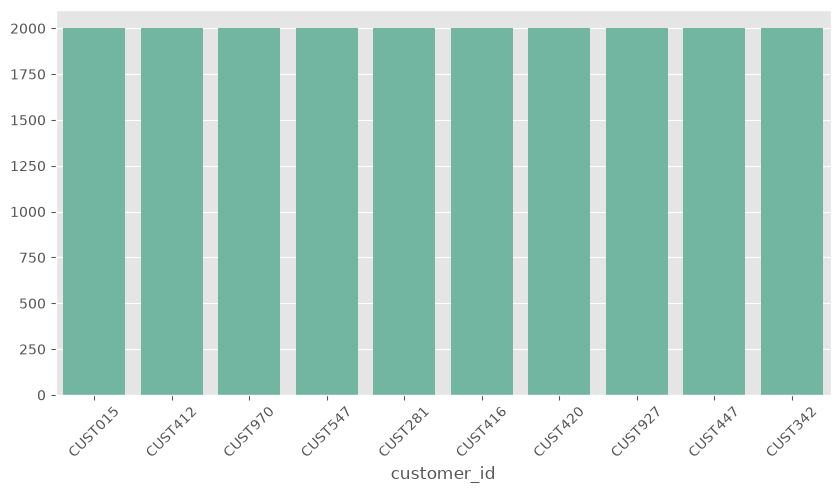

In [35]:
top_customers=(
    df.groupby("customer_id")["total_amount"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
plt.figure(figsize=(10,5))
sns.barplot(
    x=top_customers.index,
    y=top_customers.values
)
plt.xticks(rotation=45)
plt.show()

## 15. Weekend vs Weekday Sales

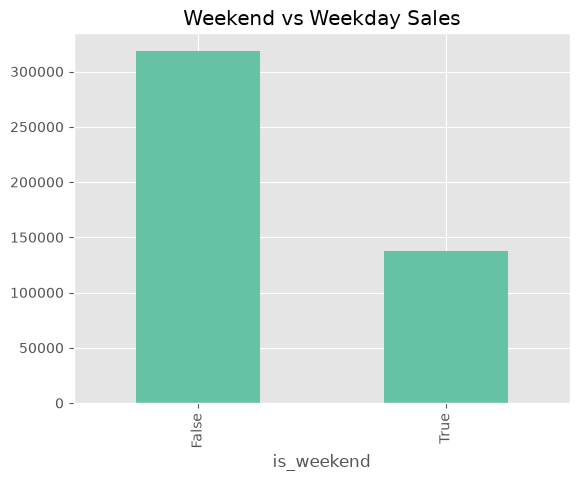

In [36]:
week = (
    df.groupby("is_weekend")["total_amount"]
      .sum()
)
week.plot(
    kind="bar"
)
plt.title("Weekend vs Weekday Sales")
plt.show()

1. Dataset Overview
Business Question

What is the overall structure and quality of the retail sales dataset?

Business Insight
The dataset contains customer demographics, product details, and transaction information required for retail sales analysis.
The data is suitable for identifying customer behavior, purchasing trends, and category performance.
Initial inspection confirms that the dataset is ready for exploratory analysis after cleaning and feature engineering.
2. Distribution of Numerical Variables
Business Question

How are customer age, quantity purchased, product prices, and spending distributed?

Business Insight
Most customers belong to a specific age range, indicating the primary target audience.
Most transactions involve a small number of purchased items, while bulk purchases are less frequent.
Product prices are concentrated within a limited range, with a few premium-priced items.
The presence of high-value transactions indicates occasional large purchases that contribute significantly to total revenue.
3. Product Category Distribution
Business Question

Which product categories receive the highest number of customer transactions?

Business Insight
The category with the highest transaction count represents the most popular product category among customers.
Categories with lower transaction counts may require promotional campaigns or improved product offerings.
Understanding purchase frequency helps optimize inventory planning and stock allocation.
4. Gender Distribution
Business Question

What is the gender composition of customers?

Business Insight
The customer base is distributed between male and female shoppers.
If one gender dominates transactions, marketing campaigns can be tailored toward that customer segment.
A balanced distribution indicates broad customer reach across genders.
5. Age Group Distribution
Business Question

Which age group contributes the highest number of transactions?

Business Insight
The dominant age group represents the primary customer segment.
Marketing campaigns should focus on this age group while exploring strategies to attract underrepresented age groups.
Customer segmentation enables personalized promotions and better targeting.
6. Monthly Sales Trend
Business Question

How do sales vary throughout the year?

Business Insight
Peak sales months indicate periods of high customer demand.
Low-performing months may require promotional offers to improve revenue.
Seasonal trends can help management forecast inventory and staffing requirements.
7. Revenue by Product Category
Business Question

Which product category generates the highest revenue?

Business Insight
The highest revenue-generating category contributes the largest share of business income.
Categories with lower revenue may require pricing optimization or marketing improvements.
Revenue analysis supports strategic investment in high-performing product lines.
8. Quantity Sold by Product Category
Business Question

Which product category sells the largest number of units?

Business Insight
High sales volume indicates products with strong customer demand.
Categories with low unit sales should be evaluated for pricing, quality, or customer preference.
Quantity analysis assists inventory planning and supply chain management.
9. Gender vs Spending
Business Question

Which gender spends more per transaction?

Business Insight
Differences in spending patterns between male and female customers provide valuable marketing insights.
The higher-spending customer segment may respond well to premium product recommendations.
Personalized promotional campaigns can improve customer engagement.
10. Product Category vs Sales
Business Question

How does spending vary across different product categories?

Business Insight
Some categories have consistently higher transaction values than others.
Categories with greater spending variation indicate diverse purchasing behavior.
Premium product categories contribute significantly to business revenue.
11. Age vs Spending
Business Question

Is customer spending influenced by age?

Business Insight
Spending behavior differs across age groups.
Customers within certain age ranges tend to make higher-value purchases.
Understanding this relationship helps create age-specific marketing campaigns and product recommendations.
12. Correlation Heatmap
Business Question

What relationships exist between numerical variables?

Business Insight
Strong positive correlations indicate variables that increase together.
Weak correlations suggest little or no direct relationship.
Understanding these relationships supports better business decision-making and predictive modeling.
13. Top Customers
Business Question

Who are the highest revenue-generating customers?

Business Insight
A small number of customers often contribute a significant portion of total revenue.
These high-value customers should be targeted through loyalty programs and exclusive offers.
Customer retention strategies should prioritize these valuable customers.
14. Weekend vs Weekday Sales
Business Question

Do customers spend more on weekends or weekdays?

Business Insight
Higher weekend sales indicate increased customer shopping activity during weekends.
If weekday sales are lower, promotional campaigns can be introduced to improve weekday revenue.
Understanding shopping patterns helps optimize staffing and inventory management.